# Simple Gaussian Model with BBVI

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=Warning)

# Generate data from a simple model: Normal(10, 1)
data = np.random.normal(loc = 10, scale = 1, size = 100)

# Manual estimation of the gradient of the ELBO

In [2]:
# Gradient estimator using sampling -- vanilla BBVI
# We here assume the model X ~ Normal(mu, 1)
# with unknown mu, that in itself is Normal, mean 0 and standard deviation 1000, 
# so effectively an uniformed prior. 
# The variational dstribution for mu is also Normal, with parameter q_mu_lambda
# -- taking the role of lambda in the calculations -- and variance 1.

def grad_estimate(q_mu_lambda, samples = 1) -> float:
    # sum_grad_estimate will hold the sum as we move along over the <samples> samples. 
    sum_grad_estimate = 0
    for i in range(samples):
        # Sample one example from current best guess for the variational distribution
        mu_sample = np.random.normal(loc=q_mu_lambda, scale=1, size=1)
        
        # Now we want to calculate the contribution from this sample, namely 
        # [log p(x, mu_sample) - log q(mu|lambda) ] * grad( log q(mu_sample|lambda) )
        #
        # First log p(x|mu_sample) + log p(mu_sample) - log q(mu_sample|lambda) 
        value = np.sum(norm.logpdf(data, loc=mu_sample, scale=1)) 
        + norm.logpdf(mu_sample, loc = 0, scale = 1000)  
        - norm.logpdf(mu_sample, loc= q_mu_lambda, scale = 1)
        
        # Next grad (log q(mu_sample|lambda))
        # The Normal distribution gives the score function with known variance as <value> - <mean>
        grad_q = mu_sample - q_mu_lambda # slide n 16 score function
        
        # grad ELBO for this sample is therefore in total given by
        sum_grad_estimate = sum_grad_estimate + grad_q * value
        
    # Divide by number of samples to get average value -- the estimated expectation  
    return sum_grad_estimate/samples

# Checking the variation in gradient estimate

M =  1 sample(s) in BBVI -- Mean of gradient:  90.060; Std.dev. of gradient: 362.235
M =  2 sample(s) in BBVI -- Mean of gradient:  93.156; Std.dev. of gradient: 260.192
M =  3 sample(s) in BBVI -- Mean of gradient: 106.831; Std.dev. of gradient: 260.599
M =  4 sample(s) in BBVI -- Mean of gradient:  98.914; Std.dev. of gradient: 190.791
M =  5 sample(s) in BBVI -- Mean of gradient: 108.806; Std.dev. of gradient: 191.716
M = 10 sample(s) in BBVI -- Mean of gradient: 116.329; Std.dev. of gradient: 127.735
M = 25 sample(s) in BBVI -- Mean of gradient: 101.396; Std.dev. of gradient:  80.243


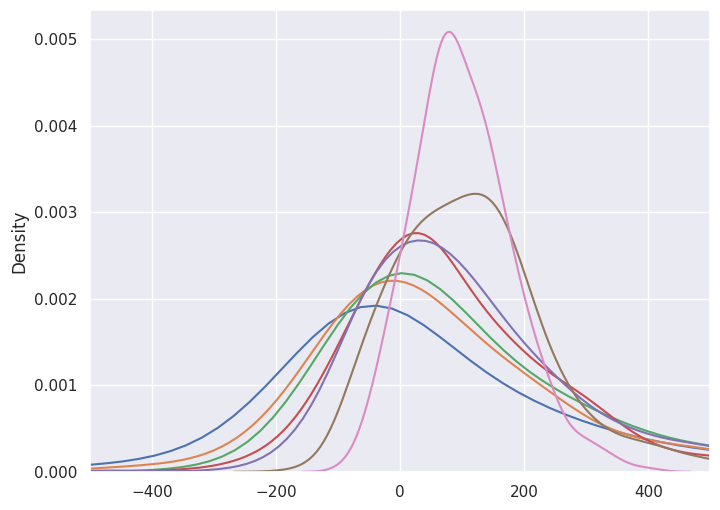

In [3]:
# To check the variation / "unreliability" of the gradient estimate we repeat 
# several times for the same lambda value and notice difference

# Location to check -- close to the data mean (at +10). 
# The prior will move the variational optimium **slightly** away from the data mean, 
# but due to the large prior variance of mu this should be a very limited effect.
# We should therefore expect a positive derivative (since we want to move 
# q_mu_lambda towards the data mean, that is, **increase** it)
q_mu_lambda = 9 # the actual was 10 but we start at 9 and we see how different sample size happens
learning_rate = 0.002

plt.figure(figsize=(8,6))
sns.set()
# Do with different sample sizes
for sample_count in [1, 2, 3, 4, 5, 10, 25]:

    #loop
    q_grad = []
    for t in range(500):
        g_estimate = grad_estimate(q_mu_lambda, samples=sample_count)
        q_grad.append(g_estimate)
        # q_mu_lambda = q_mu_lambda + learning_rate * g_estimate
    
    sns.distplot(q_grad, hist=False, label="$M = {:d}$".format(sample_count))

    # ax = sns.kdeplot(np.array(q_grad), label="$M = {:d}$".format(sample_count), ax=ax)

    
    # Report back
    print("M = {:2d} sample(s) in BBVI -- Mean of gradient: {:7.3f}; Std.dev. of gradient: {:7.3f}".format(
        sample_count, np.mean(q_grad), np.std(q_grad)))

plt.xlim([-500, 500])
plt.show()      



## Exercise

1. What can we say about the gradient estimate based on the plots above?
2. Implement and test your own gradient ascent learning algorithm starting from, say, q_mu_lambda=-10. Experiment with different learning rates, number of samples used for the gradient estimate, possibly supplemented with momentum.
3. Optional: Adapt the implementation above so that we can also learn the variance of the q distribution 

### 1. What can we say about the gradient estimate based on the plots above?

*

### 2. Implement and test your own gradient ascent learning algorithm starting from, say, q_mu_lambda=-10. Experiment with different learning rates, number of samples used for the gradient estimate, possibly supplemented with momentum.


In [4]:

import time

alpha = 0.5
lr = 0.0000001 #to be implemented with momentum

for sample_count in [1, 2, 3, 4, 5, 10, 25]:
    q_mu_lambda = -10
    v_m_l = 0

    q_grad = []
    
    start = time.perf_counter()
    for t in range(500):
        g_estimate = grad_estimate(q_mu_lambda=q_mu_lambda, samples=sample_count)
        q_grad.append(g_estimate)
        v_m_l = alpha*v_m_l - lr * g_estimate

        q_mu_lambda = q_mu_lambda + v_m_l
    end = time.perf_counter()
    
    print(f"Elapsed: {(end - start):.3f} s | Sample: {sample_count}")
    print("M = {:2d} sample(s) in BBVI -- Mean of gradient: {:7.3f}; Std.dev. of gradient: {:7.3f}".format(
        sample_count, np.mean(q_grad), np.std(q_grad)))
    
    

Elapsed: 0.224 s | Sample: 1
M =  1 sample(s) in BBVI -- Mean of gradient: 1947.041; Std.dev. of gradient: 21325.248
Elapsed: 0.536 s | Sample: 2
M =  2 sample(s) in BBVI -- Mean of gradient: 2414.466; Std.dev. of gradient: 15788.687
Elapsed: 0.643 s | Sample: 3
M =  3 sample(s) in BBVI -- Mean of gradient: 2864.211; Std.dev. of gradient: 12260.226
Elapsed: 0.868 s | Sample: 4
M =  4 sample(s) in BBVI -- Mean of gradient: 2265.676; Std.dev. of gradient: 10620.441
Elapsed: 1.132 s | Sample: 5
M =  5 sample(s) in BBVI -- Mean of gradient: 1626.258; Std.dev. of gradient: 8924.735
Elapsed: 1.867 s | Sample: 10
M = 10 sample(s) in BBVI -- Mean of gradient: 2058.787; Std.dev. of gradient: 6345.851
Elapsed: 4.213 s | Sample: 25
M = 25 sample(s) in BBVI -- Mean of gradient: 1916.522; Std.dev. of gradient: 4137.928
